# noreply Data Pipeline

**Project:** Global Geopolitical Event Prediction — Impact on USD Exchange Rate  
**Task:** 1 — Data Acquisition & Strategic Preprocessing  
**Output:** Clean JISDOR data + alignment rules

## SECTION 1: FINANCIAL DATA — JISDOR

In [1]:
# ============================================================
# SECTION 1: FINANCIAL DATA — JISDOR
# ============================================================

import os
import pandas as pd
import numpy as np
from datetime import timedelta, time

# Setup paths
DATASET_DIR = "/kaggle/input/datasets/athaurumsah/jisdor-2021-2026"
OUTPUT_DIR = "/kaggle/working/data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load
FILE_PATH = next(
    os.path.join(r, f)
    for r, _, files in os.walk(DATASET_DIR)
    for f in files if f.endswith((".xlsx", ".xls", ".csv"))
)
df = pd.read_csv(FILE_PATH) if FILE_PATH.endswith(".csv") else pd.read_excel(FILE_PATH)
df.columns = ["no", "tanggal", "kurs"]
df = df.drop(columns=["no"])

# Clean
df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")
df["kurs"] = pd.to_numeric(df["kurs"], errors="coerce")
df = df.dropna(subset=["tanggal", "kurs"]).sort_values("tanggal").reset_index(drop=True)

print(f"✓ JISDOR loaded: {len(df):,} rows, {df['tanggal'].min().date()} → {df['tanggal'].max().date()}")

✓ JISDOR loaded: 1,202 rows, 2021-09-01 → 2026-09-01


/tmp/ipykernel_58/4114604689.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")


In [2]:
# ============================================================
# SECTION 1.2: Feature Engineering + Holiday Detection
# ============================================================

# Time features
df["hari"] = df["tanggal"].dt.day_name()
df["hari_angka"] = df["tanggal"].dt.dayofweek
df["bulan"] = df["tanggal"].dt.month
df["tahun"] = df["tanggal"].dt.year
df["kuartal"] = df["tanggal"].dt.quarter

# Returns & target
df["return"] = df["kurs"].pct_change()
df["log_return"] = np.log(df["kurs"] / df["kurs"].shift(1))
df["return_next"] = df["kurs"].shift(-1) / df["kurs"] - 1
df["arah_next"] = np.where(df["return_next"] > 0, 1, 0)

# Volatility
df["volatilitas_7d"] = df["log_return"].rolling(7).std()

# Detect holidays (missing business days)
full_range = pd.date_range(df["tanggal"].min(), df["tanggal"].max(), freq="B")
missing = full_range.difference(df["tanggal"])
libur_df = pd.DataFrame({"tanggal_libur": missing})

print(f"✓ Features engineered. Holidays detected: {len(libur_df)}")

✓ Features engineered. Holidays detected: 103


In [3]:
# ============================================================
# SECTION 1.3: Alignment Rules
# ============================================================

CUTOFF_JISDOR = time(16, 15)
JISDOR_DATES = set(df["tanggal"].dt.date)
MAX_DATE = df["tanggal"].max()


def next_business_day(date):
    """Find next JISDOR business day. None if past data range."""
    if date.date() >= MAX_DATE.date():
        return None
    next_day = date + timedelta(days=1)
    for _ in range(30):
        if next_day.date() in JISDOR_DATES:
            return next_day
        next_day += timedelta(days=1)
    return None


def align_news_to_jisdor(publish_time, keyword_in_hours=False):
    """
    Alignment rules for date-level news (GDELT GKG).
    Returns dict: same_day, next_day, flags.
    """
    result = {
        "same_day": None, "next_day": None,
        "is_weekend_news": False,
        "is_aftermarket_news": False,
        "is_holiday_news": False,
        "out_of_range": False,
    }
    
    if publish_time.date() >= MAX_DATE.date():
        result["out_of_range"] = True
        return result
    
    if publish_time.weekday() >= 5:
        result["is_weekend_news"] = True
        result["next_day"] = next_business_day(publish_time)
        return result
    
    if publish_time.date() not in JISDOR_DATES:
        result["is_holiday_news"] = True
        result["next_day"] = next_business_day(publish_time)
        return result
    
    if publish_time.time() >= CUTOFF_JISDOR:
        result["is_aftermarket_news"] = True
        result["next_day"] = next_business_day(publish_time)
    else:
        result["same_day"] = publish_time
        result["next_day"] = next_business_day(publish_time)
    
    return result


# Save alignment module
import shutil
shutil.copy(__file__ if "__file__" in dir() else "/kaggle/working/alignment_rules.py",
            f"{OUTPUT_DIR}/alignment_rules.py") if os.path.exists("/kaggle/working/alignment_rules.py") else None

print("✓ Alignment rules ready.")

✓ Alignment rules ready.


In [4]:
# ============================================================
# SECTION 1.4: Export
# ============================================================

df.to_csv(f"{OUTPUT_DIR}/jisdor_clean_features.csv", index=False)
df[["tanggal", "kurs", "return", "return_next", "arah_next", "volatilitas_7d"]].to_csv(
    f"{OUTPUT_DIR}/jisdor_for_join.csv", index=False
)
libur_df.to_csv(f"{OUTPUT_DIR}/holidays.csv", index=False)

print("✓ Exported:")
print(f"  - {OUTPUT_DIR}/jisdor_clean_features.csv")
print(f"  - {OUTPUT_DIR}/jisdor_for_join.csv")
print(f"  - {OUTPUT_DIR}/holidays.csv")

✓ Exported:
  - /kaggle/working/data/processed/jisdor_clean_features.csv
  - /kaggle/working/data/processed/jisdor_for_join.csv
  - /kaggle/working/data/processed/holidays.csv


## **SECTION 2: NEWS DATA — GDELT GKG 2.0 SCRAPER**

 **Pipeline:**
 1. Download GDELT GKG 2.0 (per 15 menit, sample 1 file/hari)
 2. Filter: Trusted Sources → Geopolitical → International → Strong
 3. Top 10 articles/day by source quality
 4. Extract PAGE_TITLE from V2EXTRASXML

### **Output:** `gdelt_top10_quality.csv`

In [16]:
# ============================================================
# ============================================================
# ## SECTION 2: NEWS DATA — GDELT SCRAPER
# ### Member A
# ============================================================
# ============================================================
#
# Pipeline: GDELT GKG 2.0 → filter geopolitik (3 lapis)
#           → top 10/hari by source quality
#           → extract PAGE_TITLE
#           → fetch full article content
#
# Output: gdelt_top10_quality.csv + articles_with_text.csv

import requests
import zipfile
import io
import re
import os
import time
import datetime
import pandas as pd
from bs4 import BeautifulSoup

# --- GDELT 2.0 columns (file has NO header) ---
GKG_2_0_COLUMNS = [
    "GKGRECORDID", "V2.1DATE", "V2SOURCECOLLECTIONIDENTIFIER",
    "V2SOURCECOMMONNAME", "V2DOCUMENTIDENTIFIER",
    "V1COUNTS", "V2.1COUNTS", "V1THEMES", "V2ENHANCEDTHEMES",
    "V1LOCATIONS", "V2ENHANCEDLOCATIONS",
    "V1PERSONS", "V2ENHANCEDPERSONS",
    "V1ORGANIZATIONS", "V2ENHANCEDORGANIZATIONS",
    "V1.5TONE", "V2.1ENHANCEDDATES", "V2GCAM",
    "V2.1SHARINGIMAGE", "V2.1RELATEDIMAGES",
    "V2.1SOCIALIMAGEEMBEDS", "V2.1SOCIALVIDEOEMBEDS",
    "V2.1QUOTATIONS", "V2.1ALLNAMES", "V2.1AMOUNTS",
    "V2.1TRANSLATIONINFO", "V2EXTRASXML",
]

# --- Source quality ranking (lower = better) ---
SOURCE_QUALITY = {
    "reuters.com": 1, "apnews.com": 2, "afp.com": 3,
    "bbc.com": 4, "bbc.co.uk": 5, "nytimes.com": 6,
    "washingtonpost.com": 7, "theguardian.com": 8,
    "wsj.com": 9, "bloomberg.com": 10,
    "ft.com": 11, "economist.com": 12, "npr.org": 13, "pbs.org": 14,
    "cbc.ca": 15, "aljazeera.com": 16, "cnn.com": 17, "cnbc.com": 18,
    "scmp.com": 19, "japantimes.co.jp": 20,
    "thejakartapost.com": 31, "jakartaglobe.id": 32, "antaranews.com": 33,
    "kompas.com": 34, "tempo.co": 35, "detik.com": 36, "cnnindonesia.com": 37,
    "bisnis.com": 38, "kontan.co.id": 39, "katadata.co.id": 40,
    "indiatimes.com": 51, "thehindu.com": 52, "straitstimes.com": 53,
    "channelnewsasia.com": 54, "abc.net.au": 55, "rte.ie": 56,
    "dw.com": 57, "france24.com": 58,
}
DEFAULT_QUALITY = 999

GEOPOLITICAL_THEMES = [
    "ARMEDCONFLICT", "DIPLOMACY", "MILITARY", "REBELLION",
    "TERROR", "BORDER", "SANCTIONS",
]
STRONG_GEOPOLITICAL_THEMES = [
    "DIPLOMACY", "MILITARY_COOPERATION", "ARMEDCONFLICT", "BORDER",
    "REBELLION", "SANCTIONS",
    "WB_2473_DIPLOMACY", "WB_2470_PEACE_OPERATIONS",
    "WB_2432_FRAGILITY_CONFLICT", "WB_2462_POLITICAL_VIOLENCE",
    "WB_739_POLITICAL_VIOLENCE", "EPU_CATS_NATIONAL_SECURITY",
]

# --- Config ---
TEST_MODE = True
TOP_N_PER_DAY = 10
SAMPLE_HOUR = 0
SAMPLE_MINUTE = 0

START_DATE = datetime.date(2021, 9, 1)
END_DATE   = datetime.date(2021, 9, 30) if TEST_MODE else datetime.date(2022, 9, 1)

NEWS_DIR = "/kaggle/working/data/raw_news"
DAILY_DIR = os.path.join(NEWS_DIR, "daily")
GDELT_OUTPUT = os.path.join(NEWS_DIR, "gdelt_top10_quality.csv")
ARTICLES_OUTPUT = os.path.join(NEWS_DIR, "articles_with_text.csv")
os.makedirs(DAILY_DIR, exist_ok=True)

REQUEST_TIMEOUT = 60
MAX_ARTICLES = 100 if TEST_MODE else None

print(f"✓ Config loaded — {'TEST (10 days)' if TEST_MODE else 'PRODUCTION (1 year)'}")
print(f"  Range: {START_DATE} → {END_DATE}")
print(f"  Target: {TOP_N_PER_DAY} articles/day")

✓ Config loaded — TEST (10 days)
  Range: 2021-09-01 → 2021-09-30
  Target: 10 articles/day


In [17]:
# ============================================================
# 2.1 HELPERS + process_day()
# ============================================================

def has_any_theme(themes_str, theme_list):
    if pd.isna(themes_str):
        return False
    return any(k in str(themes_str).upper() for k in theme_list)


def count_countries(locations_str):
    if pd.isna(locations_str):
        return 0
    countries = set()
    for block in str(locations_str).split(";"):
        parts = block.split("#")
        if len(parts) >= 3 and parts[2].strip():
            countries.add(parts[2].strip())
    return len(countries)


def convert_date_to_wib(date_series):
    return pd.to_datetime(
        date_series.astype(str), format="%Y%m%d%H%M%S",
        errors="coerce", utc=True,
    ).dt.tz_convert("Asia/Jakarta")


def extract_page_title(xml_extras):
    if pd.isna(xml_extras):
        return None
    match = re.search(r'<PAGE_TITLE>(.*?)</PAGE_TITLE>', str(xml_extras))
    return match.group(1) if match else None


def source_quality_score(sources_str):
    if pd.isna(sources_str):
        return DEFAULT_QUALITY
    source_lower = str(sources_str).lower()
    best = DEFAULT_QUALITY
    for domain, score in SOURCE_QUALITY.items():
        if domain in source_lower:
            if score < best:
                best = score
            break
    return best


def parse_first_url(sourceurls_str):
    if pd.isna(sourceurls_str):
        return None
    for url in str(sourceurls_str).split("<UDIV>"):
        url = url.strip()
        if url.startswith("http"):
            return url
    return None


def process_day(date):
    """Download + filter GDELT GKG 2.0 for one day.
    NOTE: NO trusted-source filter — all sources, ranked by quality.
    """
    timestamp = date.strftime("%Y%m%d") + f"{SAMPLE_HOUR:02d}{SAMPLE_MINUTE:02d}00"
    url = f"https://data.gdeltproject.org/gdeltv2/{timestamp}.gkg.csv.zip"

    try:
        response = requests.get(url, timeout=REQUEST_TIMEOUT)
    except requests.RequestException as e:
        print(f"  [ERROR] Network: {e}")
        return None

    if response.status_code != 200:
        print(f"  [SKIP] HTTP {response.status_code}")
        return None

    try:
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            csv_name = z.namelist()[0]
            with z.open(csv_name) as f:
                daily_df = pd.read_csv(
                    f, sep="\t", header=None,
                    names=GKG_2_0_COLUMNS, low_memory=False,
                )
    except Exception as e:
        print(f"  [ERROR] Parse: {e}")
        return None

    print(f"  Raw records  : {len(daily_df):,}")

    # ---------- NO trusted filter: use ALL sources ----------
    daily_df["SOURCE_QUALITY"] = daily_df["V2SOURCECOMMONNAME"].apply(source_quality_score)
    trusted_df = daily_df.copy()  # ← all sources
    print(f"  All sources  : {len(trusted_df):,}")

    # ---------- Filter 1: Geopolitical ----------
    trusted_df["IS_GEO"] = trusted_df["V2ENHANCEDTHEMES"].apply(
        lambda t: has_any_theme(t, GEOPOLITICAL_THEMES))
    geo_df = trusted_df[trusted_df["IS_GEO"]].copy()
    if geo_df.empty:
        print("  [SKIP] No geopolitical")
        return None
    print(f"  Geopolitical : {len(geo_df):,}")

    # ---------- Filter 2: International (≥2 countries) ----------
    geo_df["COUNTRY_COUNT"] = geo_df["V2ENHANCEDLOCATIONS"].apply(count_countries)
    intl_df = geo_df[geo_df["COUNTRY_COUNT"] >= 2].copy()
    if intl_df.empty:
        print("  [SKIP] No international")
        return None
    print(f"  International: {len(intl_df):,}")

    # ---------- Filter 3: Strong geopolitical ----------
    intl_df["IS_STRONG"] = intl_df["V2ENHANCEDTHEMES"].apply(
        lambda t: has_any_theme(t, STRONG_GEOPOLITICAL_THEMES))
    strong_df = intl_df[intl_df["IS_STRONG"]].copy()
    if strong_df.empty:
        print("  [SKIP] No strong")
        return None
    print(f"  Strong       : {len(strong_df):,}")

    # ---------- Top N by source quality ----------
    final_df = strong_df.nsmallest(TOP_N_PER_DAY, "SOURCE_QUALITY").copy()
    print(f"  Top {TOP_N_PER_DAY}      : {len(final_df)} records")

    # ---------- Enrich ----------
    final_df["DATE_WIB"] = convert_date_to_wib(final_df["V2.1DATE"])
    final_df["TITLE"] = final_df["V2EXTRASXML"].apply(extract_page_title)

    # ---------- Rename ----------
    final_df = final_df.rename(columns={
        "V2SOURCECOMMONNAME": "SOURCES",
        "V2DOCUMENTIDENTIFIER": "SOURCEURLS",
        "V2ENHANCEDTHEMES": "THEMES",
        "V1.5TONE": "TONE",
        "V2.1DATE": "DATE",
    })

    # ---------- Cleanup ----------
    drop_cols = [
        "IS_GEO", "IS_STRONG", "COUNTRY_COUNT", "V2EXTRASXML",
        "GKGRECORDID", "V2SOURCECOLLECTIONIDENTIFIER",
        "V1COUNTS", "V2.1COUNTS", "V1THEMES", "V1LOCATIONS",
        "V1PERSONS", "V2ENHANCEDPERSONS", "V1ORGANIZATIONS",
        "V2ENHANCEDORGANIZATIONS", "V2.1ENHANCEDDATES", "V2GCAM",
        "V2.1SHARINGIMAGE", "V2.1RELATEDIMAGES",
        "V2.1SOCIALIMAGEEMBEDS", "V2.1SOCIALVIDEOEMBEDS",
        "V2.1QUOTATIONS", "V2.1ALLNAMES", "V2.1AMOUNTS",
        "V2.1TRANSLATIONINFO", "V2ENHANCEDLOCATIONS",
    ]
    final_df = final_df.drop(columns=drop_cols, errors="ignore")
    final_df = final_df.drop_duplicates(subset=["SOURCEURLS"], keep="first")

    return final_df


print("✓ Helpers + process_day() defined (no trusted filter)")

✓ Helpers + process_day() defined (no trusted filter)


In [18]:
import requests

try:
    r = requests.get("https://data.gdeltproject.org/gdeltv2/20210901000000.gkg.csv.zip",
                     timeout=10)
    print(f"✓ Internet OK — status: {r.status_code}")
    print(f"  Size: {len(r.content):,} bytes")
except Exception as e:
    print(f"✗ Internet OFF — {type(e).__name__}: {e}")
    print("→ Aktifkan di panel Settings → Internet → ON")

✓ Internet OK — status: 200
  Size: 5,971,961 bytes


In [19]:
# ============================================================
# 2.2 RUN GDELT SCRAPER
# ============================================================

if os.path.exists(GDELT_OUTPUT):
    os.remove(GDELT_OUTPUT)

current_date = START_DATE
total_records = 0
days_processed = 0
days_failed = 0
header_written = False

print("=" * 60)
print(f"GDELT 2.0 SCRAPER — Top {TOP_N_PER_DAY}/day")
print(f"Range : {START_DATE} → {END_DATE}")
print("=" * 60)

while current_date <= END_DATE:
    print(f"\nDate: {current_date}")
    daily_path = os.path.join(
        DAILY_DIR, f"{current_date.strftime('%Y%m%d')}_top{TOP_N_PER_DAY}.csv"
    )

    if os.path.exists(daily_path):
        print(f"  [CACHED]")
        day_df = pd.read_csv(daily_path)
    else:
        day_df = process_day(current_date)
        if day_df is not None:
            day_df.to_csv(daily_path, index=False)
        else:
            days_failed += 1
            current_date += datetime.timedelta(days=1)
            continue

    day_df.to_csv(GDELT_OUTPUT, mode="a", header=not header_written, index=False)
    header_written = True
    total_records += len(day_df)
    days_processed += 1
    current_date += datetime.timedelta(days=1)

print(f"\n✓ GDELT done: {total_records} records ({days_processed} days, {days_failed} failed)")


# ============================================================
# 2.3 RUN ARTICLE SCRAPER (FULL CONTENT)
# ============================================================

HEADERS_HTML = {
    "User-Agent": "Mozilla/5.0 (compatible; NLP-Research-Bot/1.0; Academic research)"
}
MIN_TEXT_LENGTH = 200


def extract_full_text(html):
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup(["script", "style", "nav", "header",
                     "footer", "aside", "form", "noscript",
                     "iframe", "svg"]):
        tag.decompose()
    article_body = (
        soup.find("article")
        or soup.find("div", class_=lambda c: c and "article" in c.lower())
        or soup.find("div", class_=lambda c: c and "content" in c.lower())
        or soup.find("main")
        or soup.find("body")
    )
    if article_body is None:
        return ""
    text = article_body.get_text(separator=" ", strip=True)
    return " ".join(text.split())


def fetch_article(url):
    try:
        response = requests.get(
            url, headers=HEADERS_HTML,
            timeout=15, allow_redirects=True,
        )
        response.raise_for_status()
        text = extract_full_text(response.text)
        if len(text) < MIN_TEXT_LENGTH:
            return "", "too_short"
        return text, "ok"
    except requests.RequestException as e:
        return "", f"failed: {type(e).__name__}"


if os.path.exists(ARTICLES_OUTPUT):
    os.remove(ARTICLES_OUTPUT)

df_news = pd.read_csv(GDELT_OUTPUT)
if MAX_ARTICLES:
    df_news = df_news.head(MAX_ARTICLES)

df_news["URL"] = df_news["SOURCEURLS"].apply(parse_first_url)
df_with_url = df_news[df_news["URL"].notna()].copy()

print("\n" + "=" * 60)
print(f"ARTICLE SCRAPER — {len(df_with_url)} URLs")
print("=" * 60)

results = []
for i, row in enumerate(df_with_url.itertuples(), 1):
    print(f"\n[{i}/{len(df_with_url)}] {row.URL[:80]}")
    text, status = fetch_article(row.URL)
    results.append({
        "DATE_WIB"     : getattr(row, "DATE_WIB", None),
        "TITLE"        : getattr(row, "TITLE", None),
        "THEMES"       : getattr(row, "THEMES", None),
        "TONE"         : getattr(row, "TONE", None),
        "SOURCES"      : getattr(row, "SOURCES", None),
        "URL"          : row.URL,
        "ARTICLE_TEXT" : text,
        "FETCH_STATUS" : status,
    })
    print(f"  Status: {status} | Length: {len(text):,} chars")
    time.sleep(1.0)

if results:
    pd.DataFrame(results).to_csv(ARTICLES_OUTPUT, index=False)

print(f"\n✓ Article scraper done: {ARTICLES_OUTPUT}")

GDELT 2.0 SCRAPER — Top 10/day
Range : 2021-09-01 → 2021-09-30

Date: 2021-09-01
  [CACHED]

Date: 2021-09-02
  [CACHED]

Date: 2021-09-03
  [CACHED]

Date: 2021-09-04
  [CACHED]

Date: 2021-09-05
  [CACHED]

Date: 2021-09-06
  [CACHED]

Date: 2021-09-07
  [CACHED]

Date: 2021-09-08
  [ERROR] Parse: 'utf-8' codec can't decode byte 0xe7 in position 230254: invalid continuation byte

Date: 2021-09-09
  [CACHED]

Date: 2021-09-10
  [CACHED]

Date: 2021-09-11
  [ERROR] Parse: 'utf-8' codec can't decode byte 0xe1 in position 219373: invalid continuation byte

Date: 2021-09-12
  Raw records  : 630
  All sources  : 630
  Geopolitical : 170
  International: 73
  Strong       : 56
  Top 10      : 10 records

Date: 2021-09-13
  Raw records  : 850
  All sources  : 850
  Geopolitical : 230
  International: 94
  Strong       : 73
  Top 10      : 10 records

Date: 2021-09-14
  Raw records  : 1,570
  All sources  : 1,570
  Geopolitical : 301
  International: 134
  Strong       : 116
  Top 10      : 1

In [20]:
# ============================================================
# 2.4 VERIFY OUTPUT
# ============================================================

print("=" * 60)
print("GDELT OUTPUT")
print("=" * 60)

if os.path.exists(GDELT_OUTPUT):
    df_g = pd.read_csv(GDELT_OUTPUT)
    df_g["DATE_WIB"] = pd.to_datetime(df_g["DATE_WIB"], errors="coerce")
    print(f"Shape: {df_g.shape}")
    print(f"\nRecords per day:")
    print(df_g["DATE_WIB"].dt.date.value_counts().sort_index())
    print(f"\nTop sources:")
    print(df_g["SOURCES"].value_counts().head(10))
    print(f"\nSample titles:")
    for _, r in df_g.head(5).iterrows():
        title = r['TITLE'] if pd.notna(r['TITLE']) else "(no title)"
        print(f"  [{r['DATE_WIB'].date()}] {title[:70]}")
        print(f"    Source: {r['SOURCES']} | Quality: {r['SOURCE_QUALITY']}")
else:
    print("✗ GDELT output not found")

print("\n" + "=" * 60)
print("ARTICLE OUTPUT")
print("=" * 60)

if os.path.exists(ARTICLES_OUTPUT):
    df_a = pd.read_csv(ARTICLES_OUTPUT)
    print(f"Shape: {df_a.shape}")
    print(f"\nFetch status:")
    print(df_a["FETCH_STATUS"].value_counts())
    ok = df_a[df_a["FETCH_STATUS"] == "ok"]
    if len(ok) > 0:
        lens = ok["ARTICLE_TEXT"].str.len()
        print(f"\nText length (ok only):")
        print(f"  Mean:   {lens.mean():,.0f}")
        print(f"  Median: {lens.median():,.0f}")
        print(f"  Max:    {lens.max():,.0f}")
else:
    print("✗ Article output not found")

GDELT OUTPUT
Shape: (208, 8)

Records per day:
DATE_WIB
2021-09-01     7
2021-09-02    10
2021-09-03     2
2021-09-04    10
2021-09-05     2
2021-09-06     2
2021-09-07     4
2021-09-09     3
2021-09-10     8
2021-09-12    10
2021-09-13    10
2021-09-14    10
2021-09-16    10
2021-09-17    10
2021-09-19    10
2021-09-20    10
2021-09-21    10
2021-09-22    10
2021-09-23    10
2021-09-24    10
2021-09-25    10
2021-09-27    10
2021-09-28    10
2021-09-29    10
2021-09-30    10
Name: count, dtype: int64

Top sources:
SOURCES
washingtonpost.com    18
reuters.com            9
nytimes.com            9
apnews.com             8
france24.com           7
bbc.co.uk              6
indiatimes.com         6
theguardian.com        6
dw.com                 4
npr.org                4
Name: count, dtype: int64

Sample titles:
  [2021-09-01] Afghanistan: The questions facing Foreign Secretary Dominic Raab
    Source: bbc.co.uk | Quality: 5
  [2021-09-01] Marseille drugs: Child victims of French city's v

## SECTION 3: TEXT PREPROCESSING

 Pipeline:
   1. Handle NaN / empty text
   2. Remove URLs & HTML entities
   3. Remove punctuation (keep apostrophes for contractions)
   4. Lowercase
   5. Expand contractions (don't → do not)
   6. Tokenize
   7. Remove stopwords (KEEP negation words for sentiment)
   8. Lemmatize (better than stemming for readability)

### Output: df with 'title_tokens' and 'text_tokens' columns


In [23]:
# ============================================================
# INSTALL DEPENDENCIES (Section 3)
# ============================================================

!pip install contractions wordcloud nltk -q

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("✓ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.7 MB/s eta 0:00:00
✓ Dependencies installed


In [24]:
import re
import string
import pandas as pd
import nltk
import contractions
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- Download NLTK resources (hanya sekali) ---
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# --- Custom: words to KEEP (jangan dihapus) ---
KEEP_WORDS = {
    # Negations — penting untuk sentiment
    "no", "not", "nor", "none", "never", "neither",
    "without", "against", "but", "however",
    # Geopolitical keywords — penting untuk topic
    "war", "peace", "attack", "strike", "sanction",
    "conflict", "military", "diplomacy", "border",
    "rise", "fall", "increase", "decrease",
    "up", "down",
    # Country/region names
    "us", "usa", "china", "russia", "ukraine", "israel",
    "iran", "north", "korea", "taiwan", "indo",
    "indonesia", "asia", "europe", "america", "afghanistan",
}


def process_text(
    message,
    remove_urls=True,
    remove_html=True,
    punctuation=True,
    lower_case=True,
    contract=True,
    tokenize=True,
    stop_words=True,
    lemmatize=True,
):
    """
    Preprocess a text message for NLP tasks.

    Steps:
        - Remove URLs and HTML entities
        - Remove punctuation
        - Lowercase
        - Expand contractions (don't → do not)
        - Tokenize
        - Remove stopwords (KEEP negation words)
        - Lemmatize

    Returns:
        list: clean tokens
    """
    if not isinstance(message, str) or not message.strip():
        return []

    # 1. Remove URLs
    if remove_urls:
        message = re.sub(r"http\S+|www\.\S+", "", message)

    # 2. Remove HTML entities
    if remove_html:
        message = re.sub(r"<.*?>", "", message)
        message = re.sub(r"&[a-z]+;", " ", message)

    # 3. Remove punctuation
    if punctuation:
        for punct in string.punctuation:
            message = message.replace(punct, " ")

    # 4. Lowercase
    if lower_case:
        message = message.lower()

    # 5. Expand contractions
    if contract:
        message = contractions.fix(message)

    # 6. Tokenize
    if tokenize:
        words = word_tokenize(message)
    else:
        words = message.split()

    # 7. Remove stopwords (KEEP KEEP_WORDS)
    if stop_words:
        sw = set(stopwords.words("english")).difference(KEEP_WORDS)
        words = [w for w in words if w not in sw]

    # 8. Lemmatize
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        words = [lemmatizer.lemmatize(w) for w in words if w.strip()]

    # Filter empty & very short tokens
    words = [w for w in words if len(w) > 1]

    return words


# ============================================================
# APPLY PREPROCESSING TO NEWS DATA
# ============================================================

# Load articles
ARTICLES_PATH = "/kaggle/working/data/raw_news/articles_with_text.csv"
df = pd.read_csv(ARTICLES_PATH)

print(f"Loaded: {len(df)} articles")
print(f"Columns: {list(df.columns)}")

# Filter to successfully fetched articles only
df_ok = df[df["FETCH_STATUS"] == "ok"].copy()
print(f"Articles with full text: {len(df_ok)}")

# Apply preprocessing to TITLE
df_ok["title_tokens"] = df_ok["TITLE"].apply(process_text)

# Apply preprocessing to ARTICLE_TEXT
df_ok["text_tokens"] = df_ok["ARTICLE_TEXT"].apply(process_text)

# Convert tokens to string for CSV export
df_ok["title_clean"] = df_ok["title_tokens"].apply(lambda x: " ".join(x))
df_ok["text_clean"] = df_ok["text_tokens"].apply(lambda x: " ".join(x))

print(f"\n✓ Preprocessing done")
print(f"\nSample results:")
for _, row in df_ok.head(3).iterrows():
    print(f"\nOriginal title: {row['TITLE'][:80]}")
    print(f"Cleaned title:  {row['title_clean'][:80]}")
    print(f"Title tokens:   {row['title_tokens'][:10]}")

# Export
df_ok.to_csv("/kaggle/working/data/processed/news_preprocessed.csv", index=False)
print(f"\n✓ Saved: news_preprocessed.csv")

Loaded: 100 articles
Columns: ['DATE_WIB', 'TITLE', 'THEMES', 'TONE', 'SOURCES', 'URL', 'ARTICLE_TEXT', 'FETCH_STATUS']
Articles with full text: 45

✓ Preprocessing done

Sample results:

Original title: Afghanistan: The questions facing Foreign Secretary Dominic Raab
Cleaned title:  afghanistan question facing foreign secretary dominic raab
Title tokens:   ['afghanistan', 'question', 'facing', 'foreign', 'secretary', 'dominic', 'raab']

Original title: Marseille drugs: Child victims of French city's vicious gang war
Cleaned title:  marseille drug child victim french city vicious gang war
Title tokens:   ['marseille', 'drug', 'child', 'victim', 'french', 'city', 'vicious', 'gang', 'war']

Original title: Biden defends Afghanistan exit again as Taliban declares victory over U.S.
Cleaned title:  biden defends afghanistan exit taliban declares victory
Title tokens:   ['biden', 'defends', 'afghanistan', 'exit', 'taliban', 'declares', 'victory']

✓ Saved: news_preprocessed.csv


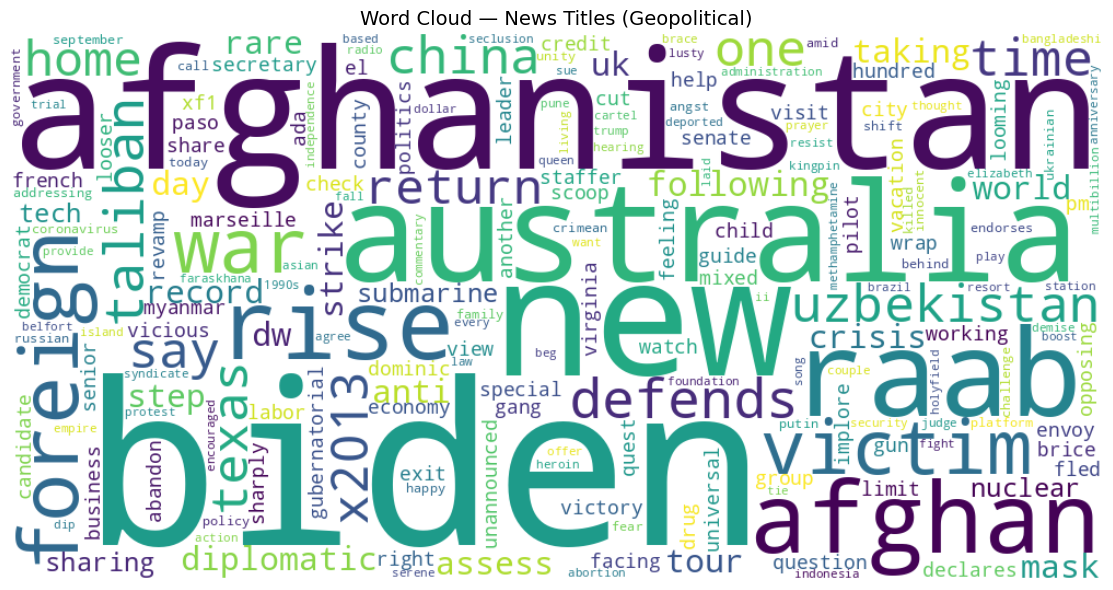

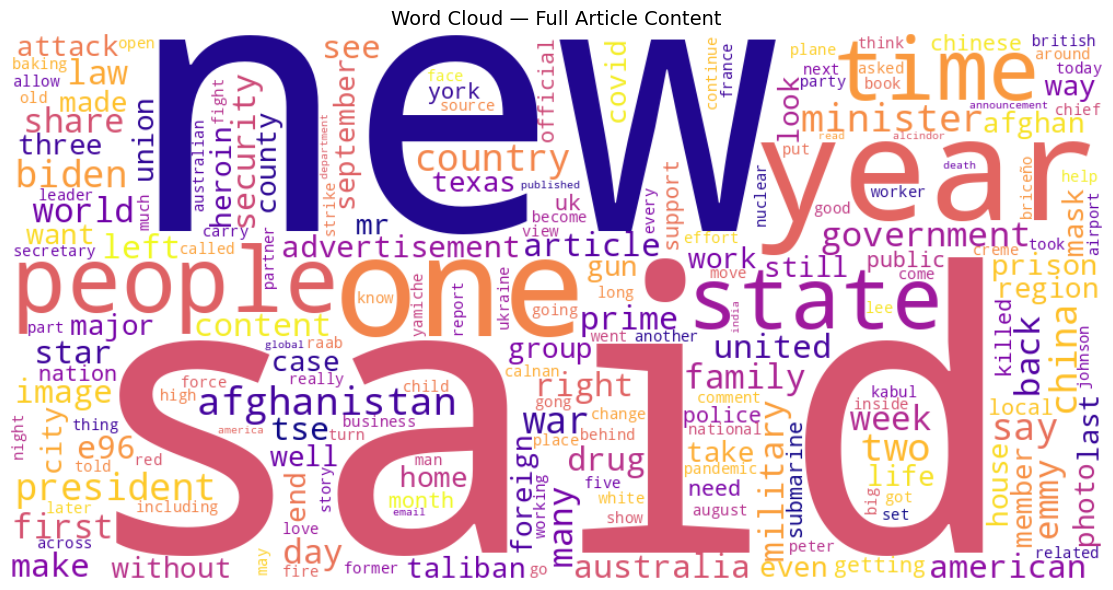

In [25]:
# ============================================================
# ============================================================
# ## SECTION 3.2: WORD CLOUD VISUALIZATION
# ============================================================
# ============================================================

import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --- Word Cloud 1: All Titles ---
title_text = " ".join(df_ok["title_clean"].dropna())

wordcloud_title = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200,
    colormap="viridis",
    random_state=42,
    collocations=False,
).generate(title_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_title, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — News Titles (Geopolitical)", fontsize=14)
plt.tight_layout()
plt.show()


# --- Word Cloud 2: All Article Text ---
article_text = " ".join(df_ok["text_clean"].dropna())

wordcloud_article = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200,
    colormap="plasma",
    random_state=42,
    collocations=False,
).generate(article_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_article, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Full Article Content", fontsize=14)
plt.tight_layout()
plt.show()